# Analiza podatkov: zaupanje skozi čas v sistem XAI

Magistrsko delo — *Zaupanje skozi čas: kako razlage vplivajo na dolgoročno zaupanje v sistem umetne inteligence*

**Podatki:** `anketa191776-2026-05-11_dataset_analiza_v13.csv`
Uporabljaj izključno različico **v13** ali novejšo. Starejše različice vsebujejo napake pri
čiščenju lestvic Q2 (1–7) in Q4B (1–5).

**Zgradba analize:**
1. Priprava podatkov
2. Eksploratorna analiza (grafi za hiter pregled)
3. Linearni mešani modeli — najprej zaupanje, nato ostale dimenzije

**Merjene dimenzije in njihove lestvice:**

| Dimenzija | Postavke | Lestvica | Cronbach α |
|---|---|---|---|
| Zaupanje | Q4Aa–Q4Ag | 1–7 | 0,946 |
| Nezaupanje | Q4Ba–Q4Be | 1–5 | 0,808 |
| Zadovoljstvo z razlago | Q2a–Q2h | 1–7 | 0,934 |
| Izvedljivost | Q3a–Q3g | 1–5 | 0,892 |
| Mentalni model | 11 nalog | delež 0–1 | — |

## 1. Priprava podatkov

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 60)

PODATKI = "../Izvozi/analysis_outputs_2026_05_11/anketa191776-2026-05-11_dataset_analiza_v13.csv"
GRAFI = Path("grafi")
GRAFI.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

In [2]:
df = pd.read_csv(PODATKI, encoding="utf-8-sig")

# Obdrzimo samo veljavne enote: zakljucena anketa, brez testnih vnosov,
# z razresljivo 8-mestno kodo udelezenca.
df = df[df["analiza_valid_resolved"] == True].copy()

# Tip pristranskosti kot faktor. Referencna kategorija je "brez_biasa",
# zato se oba pristranska pogoja primerjata z njo.
df["bias"] = pd.Categorical(
    df["analiza_bias_type"],
    categories=["brez_biasa", "pozitivni_bias_nacionalnost", "negativni_bias_nacionalnost"],
)

print(f"Veljavnih enot:  {len(df)}")
print(f"Udelezencev:     {df['analiza_resolved_code'].nunique()}")
print(f"Zaporednih ogledov: {int(df['analiza_view_number'].min())}-{int(df['analiza_view_number'].max())}")
df["bias"].value_counts()

Veljavnih enot:  267
Udelezencev:     82
Zaporednih ogledov: 1-6


bias
brez_biasa                     180
negativni_bias_nacionalnost     45
pozitivni_bias_nacionalnost     42
Name: count, dtype: int64

In [3]:
# Slovarji za dimenzije: ime -> (stolpec, lestvica)
DIMENZIJE = {
    "Zaupanje":               ("analiza_faktor_zaupanje_mean",      "1-7"),
    "Nezaupanje":             ("analiza_faktor_nezaupanje_mean",    "1-5"),
    "Zadovoljstvo z razlago": ("analiza_zadovoljstvo_q2_mean",      "1-7"),
    "Izvedljivost":           ("analiza_izvedljivost_q3_mean",      "1-5"),
    "Mentalni model":         ("analiza_mm_total_correct_share",    "0-1"),
}

opis = pd.DataFrame(
    [
        {
            "dimenzija": ime,
            "lestvica": lestvica,
            "N": int(df[stolpec].notna().sum()),
            "M": round(df[stolpec].mean(), 2),
            "SD": round(df[stolpec].std(), 2),
            "min": round(df[stolpec].min(), 2),
            "max": round(df[stolpec].max(), 2),
        }
        for ime, (stolpec, lestvica) in DIMENZIJE.items()
    ]
)
opis

,dimenzija,lestvica,N,M,SD,min,max
0,Zaupanje,1-7,238,4.05,1.36,1.00,7.00
1,Nezaupanje,1-5,238,2.79,0.81,1.00,5.00
2,Zadovoljstvo z razlago,1-7,267,4.61,1.23,1.12,7.00
3,Izvedljivost,1-5,267,3.54,0.75,1.57,5.00
4,Mentalni model,0-1,267,0.38,0.17,0.00,0.82


> **Opomba k N.** Zaupanje in nezaupanje imata manj enot (238) kot ostale dimenzije (267),
> ker je del udeležencev izpolnil starejšo različico lestvice zaupanja, ki je ni mogoče
> primerjati z novo. Te enote so označene z `analiza_trust_version = "old"` in izločene.
> To je treba navesti v poglavju o omejitvah.

## 2. Eksploratorna analiza

### 2.1 Število sodelovanj

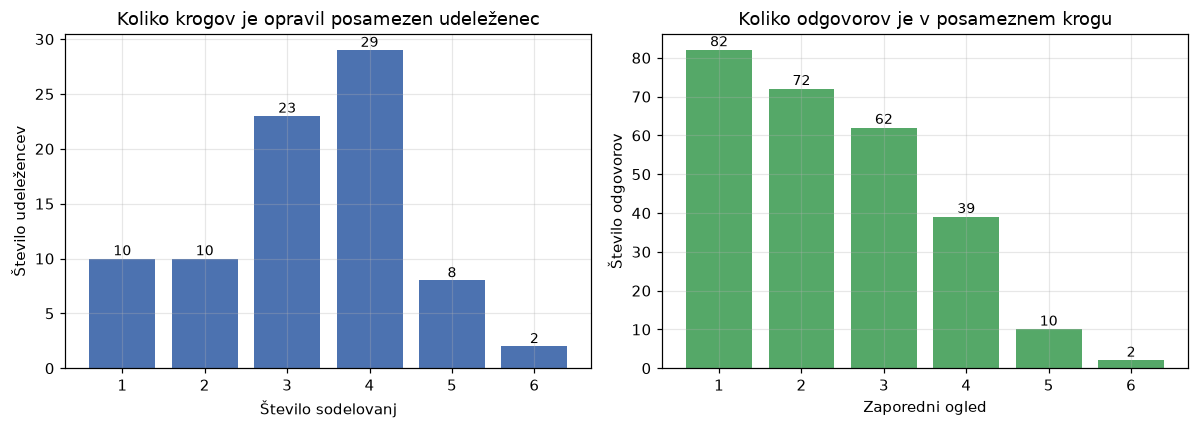

Povprecno sodelovanj na udelezenca: 3.26
Krogi 5 in 6 skupaj: 12 odgovorov


In [4]:
sodelovanja = df.groupby("analiza_resolved_code").size()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

porazdelitev = sodelovanja.value_counts().sort_index()
ax1.bar(porazdelitev.index, porazdelitev.values, color="#4C72B0")
ax1.set_xlabel("Število sodelovanj")
ax1.set_ylabel("Število udeležencev")
ax1.set_title("Koliko krogov je opravil posamezen udeleženec")
for x, y in zip(porazdelitev.index, porazdelitev.values):
    ax1.text(x, y + 0.3, str(y), ha="center", fontsize=9)

po_ogledih = df.groupby("analiza_view_number").size()
ax2.bar(po_ogledih.index, po_ogledih.values, color="#55A868")
ax2.set_xlabel("Zaporedni ogled")
ax2.set_ylabel("Število odgovorov")
ax2.set_title("Koliko odgovorov je v posameznem krogu")
for x, y in zip(po_ogledih.index, po_ogledih.values):
    ax2.text(x, y + 1, str(y), ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(GRAFI / "01_sodelovanja.png", bbox_inches="tight")
plt.show()

print(f"Povprecno sodelovanj na udelezenca: {sodelovanja.mean():.2f}")
print(f"Krogi 5 in 6 skupaj: {int(po_ogledih.get(5, 0) + po_ogledih.get(6, 0))} odgovorov")

Kroga 5 in 6 sta skoraj prazna. Zato čas v modelu obravnavamo kot **zvezno** spremenljivko
(linearni trend) in ne kot faktor — za faktor bi bili ti dve oceni nezanesljivi.

### 2.2 Povprečni odgovori po postavkah

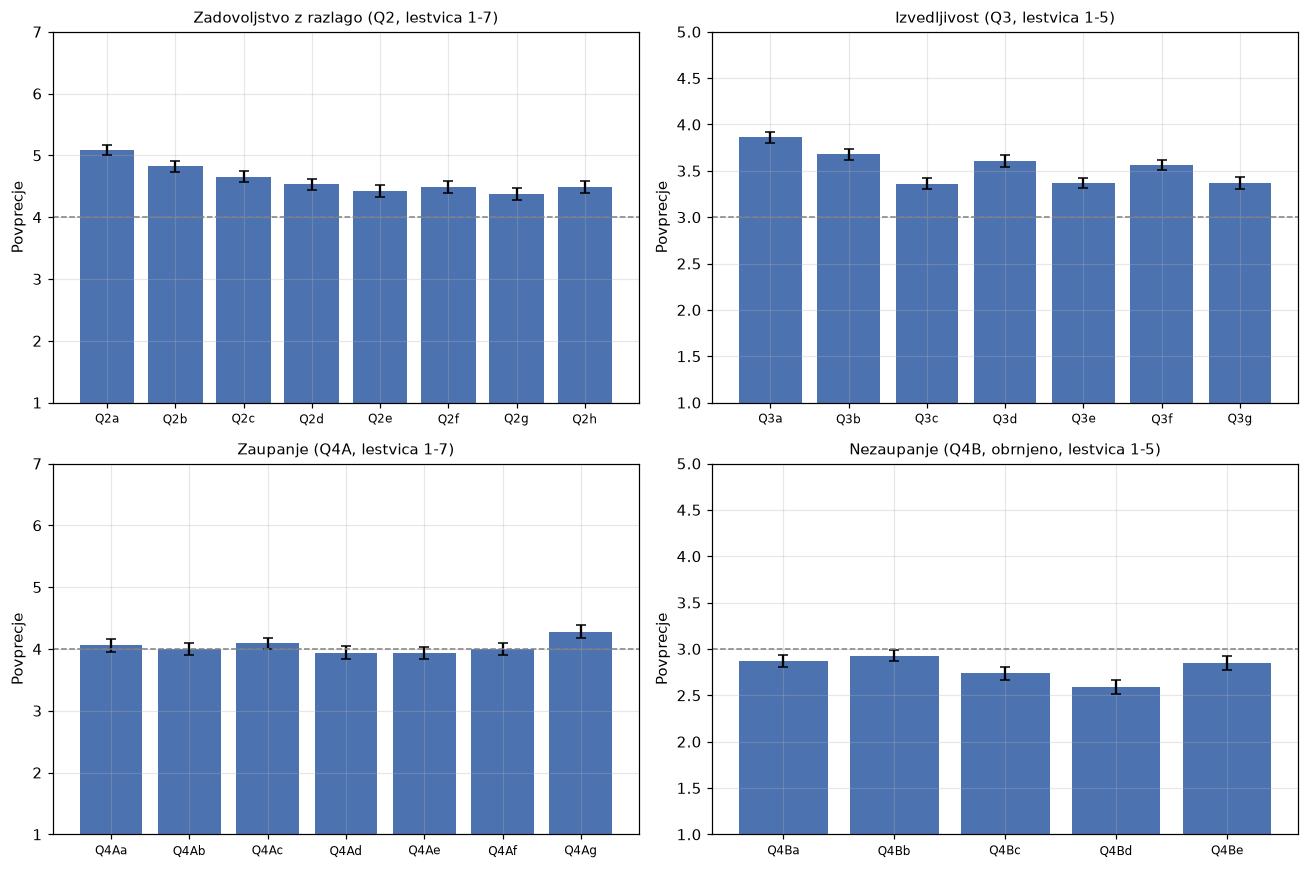

In [5]:
SKLOPI = {
    "Zadovoljstvo z razlago (Q2, lestvica 1-7)": (
        [f"analiza_zadovoljstvo_q2{c}_clean_1_7" for c in "abcdefgh"],
        [f"Q2{c}" for c in "abcdefgh"],
        7,
    ),
    "Izvedljivost (Q3, lestvica 1-5)": (
        [f"analiza_izvedljivost_q3{c}_clean_1_5" for c in "abcdefg"],
        [f"Q3{c}" for c in "abcdefg"],
        5,
    ),
    "Zaupanje (Q4A, lestvica 1-7)": (
        [f"analiza_trust_new_q4a{c}" for c in "abcdefg"],
        [f"Q4A{c}" for c in "abcdefg"],
        7,
    ),
    "Nezaupanje (Q4B, obrnjeno, lestvica 1-5)": (
        [f"analiza_nezaupanje_t{i}_recoded_1_5" for i in range(1, 6)],
        [f"Q4B{c}" for c in "abcde"],
        5,
    ),
}

fig, osi = plt.subplots(2, 2, figsize=(12, 8))
for ax, (naslov, (stolpci, oznake, vrh)) in zip(osi.flat, SKLOPI.items()):
    povprecja = [pd.to_numeric(df[s], errors="coerce").mean() for s in stolpci]
    napake = [
        pd.to_numeric(df[s], errors="coerce").sem() for s in stolpci
    ]
    ax.bar(oznake, povprecja, yerr=napake, capsize=3, color="#4C72B0")
    ax.set_ylim(1, vrh)
    ax.axhline((1 + vrh) / 2, color="grey", linestyle="--", linewidth=1)
    ax.set_title(naslov, fontsize=10)
    ax.set_ylabel("Povprecje")
    ax.tick_params(axis="x", labelsize=8)

plt.tight_layout()
plt.savefig(GRAFI / "02_povprecja_postavk.png", bbox_inches="tight")
plt.show()

Črtkana črta je sredina lestvice. Pri nezaupanju je smer obrnjena: **višja vrednost pomeni
večje nezaupanje**.

### 2.3 Pravilnost mentalnega modela

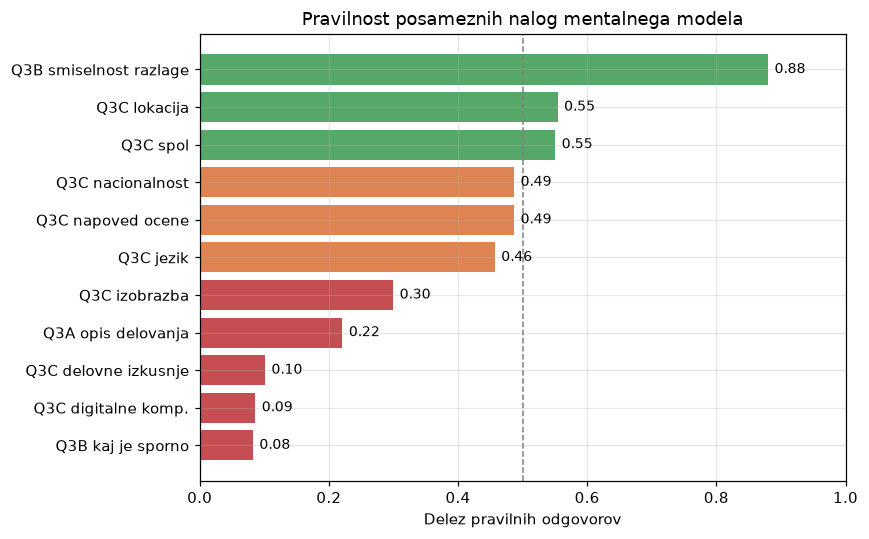

Skupni delez pravilnih: 0.382


In [6]:
MM_STOLPCI = {
    "analiza_mm_q3a_correct": "Q3A opis delovanja",
    "analiza_mm_q3b2_correct": "Q3B smiselnost razlage",
    "analiza_mm_q3b3_correct": "Q3B kaj je sporno",
    "analiza_mm_q3c2_correct": "Q3C napoved ocene",
    "analiza_mm_q3c_3a_correct": "Q3C izobrazba",
    "analiza_mm_q3c_3b_correct": "Q3C delovne izkusnje",
    "analiza_mm_q3c_3c_correct": "Q3C jezik",
    "analiza_mm_q3c_3d_correct": "Q3C digitalne komp.",
    "analiza_mm_q3c_3e_correct": "Q3C spol",
    "analiza_mm_q3c_3f_correct": "Q3C lokacija",
    "analiza_mm_q3c_3g_correct": "Q3C nacionalnost",
}

delezi = pd.Series(
    {opis: pd.to_numeric(df[st], errors="coerce").mean() for st, opis in MM_STOLPCI.items()}
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
barve = ["#C44E52" if v < 0.33 else "#DD8452" if v < 0.5 else "#55A868" for v in delezi.values]
ax.barh(delezi.index, delezi.values, color=barve)
ax.set_xlabel("Delez pravilnih odgovorov")
ax.set_xlim(0, 1)
ax.axvline(0.5, color="grey", linestyle="--", linewidth=1)
ax.set_title("Pravilnost posameznih nalog mentalnega modela")
for i, v in enumerate(delezi.values):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(GRAFI / "03_mentalni_model.png", bbox_inches="tight")
plt.show()

print(f"Skupni delez pravilnih: {df['analiza_mm_total_correct_share'].mean():.3f}")

### 2.4 Potek dimenzij skozi kroge

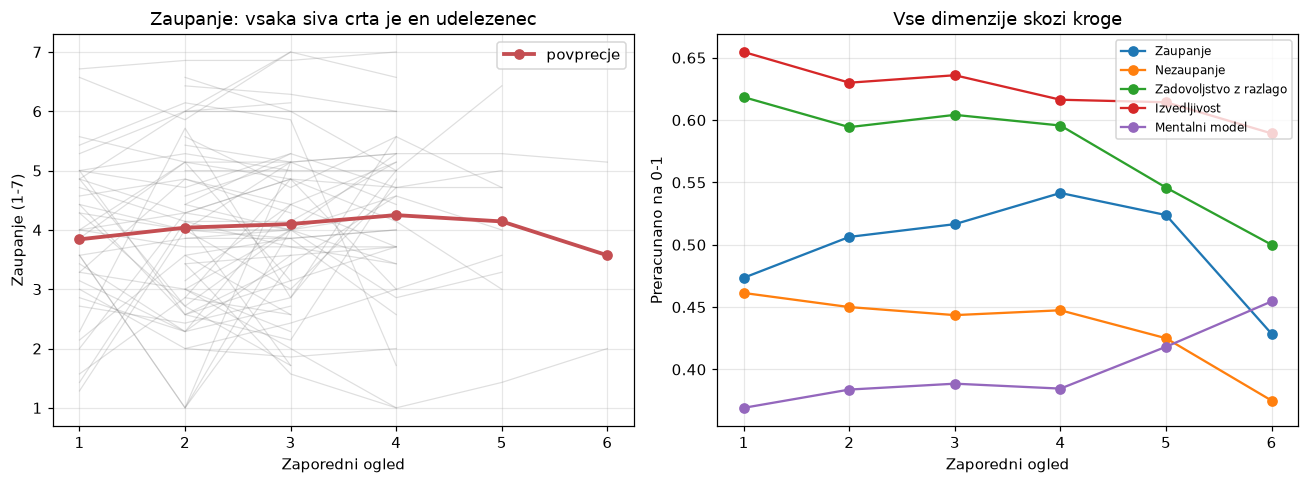

In [7]:
fig, osi = plt.subplots(1, 2, figsize=(12, 4.5))

# Levo: posamezne poti udelezencev z vsaj tremi meritvami zaupanja.
d_trust = df.dropna(subset=["analiza_faktor_zaupanje_mean"])
for _, skupina in d_trust.groupby("analiza_resolved_code"):
    if len(skupina) >= 3:
        skupina = skupina.sort_values("analiza_view_number")
        osi[0].plot(
            skupina["analiza_view_number"],
            skupina["analiza_faktor_zaupanje_mean"],
            color="grey", alpha=0.25, linewidth=0.8,
        )
povpr = d_trust.groupby("analiza_view_number")["analiza_faktor_zaupanje_mean"].mean()
osi[0].plot(povpr.index, povpr.values, color="#C44E52", linewidth=2.5, marker="o", label="povprecje")
osi[0].set_xlabel("Zaporedni ogled")
osi[0].set_ylabel("Zaupanje (1-7)")
osi[0].set_title("Zaupanje: vsaka siva crta je en udelezenec")
osi[0].legend()

# Desno: vse dimenzije, preracunane na 0-1 zaradi primerljivosti.
for ime, (stolpec, lestvica) in DIMENZIJE.items():
    serija = df.groupby("analiza_view_number")[stolpec].mean()
    if lestvica == "1-7":
        serija = (serija - 1) / 6
    elif lestvica == "1-5":
        serija = (serija - 1) / 4
    osi[1].plot(serija.index, serija.values, marker="o", label=ime)
osi[1].set_xlabel("Zaporedni ogled")
osi[1].set_ylabel("Preracunano na 0-1")
osi[1].set_title("Vse dimenzije skozi kroge")
osi[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(GRAFI / "04_potek_skozi_kroge.png", bbox_inches="tight")
plt.show()

Levi graf pokaže, zakaj navadni testi tu ne delujejo: udeleženci se med seboj razlikujejo
veliko bolj kot se posameznik spreminja skozi čas. Prav to razliko mešani model odstrani.

## 3. Linearni mešani modeli

**Zakaj mešani model.** Podatki niso neodvisni — 267 odgovorov prihaja od 82 udeležencev,
vsak je odgovarjal do šestkrat. Navadni test bi predpostavil 267 neodvisnih oseb in dal
prenizke *p*-vrednosti.

**Zgradba modela po specifikaciji analize:**

```
Kaj napovedujemo = čas * bias (1+id)
Glede na excel spremenljivke: Biased * analiza_view_number
```

Pomen posameznih elementov:

| Element | Pomen |
|---|---|
| `*` | upošteva interakcijo pristranskosti in časa |
| `(1+id)` | grupiranje po ID udeleženca |
| odvisna spremenljivka | zaupanje, nezaupanje ali zadovoljstvo |

V `statsmodels` se to zapiše kot:

```python
smf.mixedlm("odvisna ~ analiza_view_number * Biased", d, groups=d["analiza_resolved_code"])
```

- **Fiksni učinki** — čas, pristranskost in njuna **interakcija**
- **Naključni učinek** — vsak udeleženec dobi svoje izhodišče, zato model meri spremembo
  *znotraj* osebe. V `statsmodels` je naključni presek privzet, ko podaš `groups=`.

Kako brati koeficient pri času: če je pozitiven, vrednost raste, če je negativen, pada.

### 3.1 Zaupanje, nezaupanje in zadovoljstvo

In [8]:
def mesani_model(podatki, odvisna, oznaka, napovednik="analiza_view_number * Biased"):
    """Prilagodi linearni mesani model po specifikaciji analize.

    Privzeta formula je "cas * bias", grupirana po ID udelezenca.
    """
    d = podatki.dropna(subset=[odvisna, "analiza_view_number"]).copy()
    model = smf.mixedlm(
        f"{odvisna} ~ {napovednik}", d, groups=d["analiza_resolved_code"]
    ).fit()

    var_med = float(model.cov_re.iloc[0, 0])
    icc = var_med / (var_med + model.scale)

    print(f"=== {oznaka} ===")
    print(f"formula: {odvisna} ~ {napovednik}  + (1 | id)")
    print(f"N = {len(d)} odgovorov, {d['analiza_resolved_code'].nunique()} udelezencev")
    print(f"ICC = {icc:.3f}  (delez variance zaradi razlik med udelezenci)")
    print(model.summary().tables[1])
    print()
    return model


modeli = {}
for ime in ["Zaupanje", "Nezaupanje", "Zadovoljstvo z razlago"]:
    stolpec = DIMENZIJE[ime][0]
    modeli[ime] = mesani_model(df, stolpec, ime.upper())

=== ZAUPANJE ===
formula: analiza_faktor_zaupanje_mean ~ analiza_view_number * Biased  + (1 | id)
N = 238 odgovorov, 80 udelezencev
ICC = 0.544  (delez variance zaradi razlik med udelezenci)
                             Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept                    3.794    0.225  16.874  0.000   3.354  4.235
analiza_view_number          0.103    0.071   1.460  0.144  -0.035  0.242
Biased                      -0.077    0.345  -0.224  0.823  -0.752  0.598
analiza_view_number:Biased   0.023    0.123   0.186  0.853  -0.218  0.264
Group Var                    0.991    0.274                              

=== NEZAUPANJE ===
formula: analiza_faktor_nezaupanje_mean ~ analiza_view_number * Biased  + (1 | id)
N = 238 odgovorov, 80 udelezencev
ICC = 0.430  (delez variance zaradi razlik med udelezenci)
                             Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept                    2.825    0.143  19.689  0.000   2.544  3.106
analiza_view_number  

=== ZADOVOLJSTVO Z RAZLAGO ===
formula: analiza_zadovoljstvo_q2_mean ~ analiza_view_number * Biased  + (1 | id)
N = 267 odgovorov, 82 udelezencev
ICC = 0.604  (delez variance zaradi razlik med udelezenci)
                             Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept                    4.543    0.174  26.051  0.000   4.202  4.885
analiza_view_number          0.023    0.053   0.432  0.665  -0.081  0.127
Biased                       0.379    0.257   1.475  0.140  -0.125  0.882
analiza_view_number:Biased  -0.150    0.096  -1.559  0.119  -0.338  0.039
Group Var                    0.912    0.280                              



**Kako brati izpis:**

| Vrstica | Pomen |
|---|---|
| `Intercept` | Pričakovana vrednost pri nepristranskem primeru, izhodiščni ogled |
| `analiza_view_number` | Sprememba **na vsak nadaljnji ogled**. Pozitiven = raste, negativen = pada |
| `Biased` | Razlika med pristranskim in nepristranskim primerom |
| `analiza_view_number:Biased` | **Interakcija** — ali se učinek pristranskosti spreminja skozi čas |
| `Group Var` | Koliko se udeleženci med seboj razlikujejo |
| `ICC` | Delež variance, ki gre na račun razlik med udeleženci |

`P>|z|` pod 0,05 pomeni statistično značilen učinek.

**Preverjanje prekomernega zaupanja (RV2).** Merilo je: če zaupanje v bias
primerih skozi čas ne upada, gre za prekomerno zaupanje. To odčitaš iz interakcije: če je koeficient pri
`analiza_view_number:Biased` pozitiven ali blizu nič, zaupanje pri pristranskih primerih
skozi čas ne upada — kar je znak prekomernega zaupanja.

### 3.2 Mentalni model

Specifikacija: pravilnost mentalnega modela = bias * čas.

In [9]:
modeli["Mentalni model"] = mesani_model(
    df, "analiza_mm_total_correct_share", "PRAVILNOST MENTALNEGA MODELA"
)

# Razsirjeni model kot dodatni poskus:
# X = bias * cas * pravilnost MM -> pravilnost MM kot dodaten napovednik zaupanja.
modeli["Zaupanje + MM"] = mesani_model(
    df,
    "analiza_faktor_zaupanje_mean",
    "ZAUPANJE z vkljucenim mentalnim modelom",
    napovednik="analiza_view_number * Biased * analiza_mm_total_correct_share",
)

=== PRAVILNOST MENTALNEGA MODELA ===
formula: analiza_mm_total_correct_share ~ analiza_view_number * Biased  + (1 | id)
N = 267 odgovorov, 82 udelezencev
ICC = 0.365  (delez variance zaradi razlik med udelezenci)
                             Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept                    0.348    0.026  13.476  0.000   0.297  0.398
analiza_view_number          0.014    0.009   1.612  0.107  -0.003  0.032
Biased                       0.037    0.042   0.876  0.381  -0.046  0.119
analiza_view_number:Biased  -0.013    0.016  -0.819  0.413  -0.044  0.018
Group Var                    0.010    0.022                              



=== ZAUPANJE z vkljucenim mentalnim modelom ===
formula: analiza_faktor_zaupanje_mean ~ analiza_view_number * Biased * analiza_mm_total_correct_share  + (1 | id)
N = 238 odgovorov, 80 udelezencev
ICC = 0.550  (delez variance zaradi razlik med udelezenci)
                                                            Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept                                                   4.588    0.532   8.620  0.000   3.545  5.632
analiza_view_number                                        -0.049    0.184  -0.266  0.790  -0.409  0.311
Biased                                                     -0.627    0.958  -0.655  0.513  -2.504  1.250
analiza_view_number:Biased                                  0.286    0.345   0.830  0.407  -0.390  0.963
analiza_mm_total_correct_share                             -2.102    1.237  -1.700  0.089  -4.525  0.322
analiza_view_number:analiza_mm_total_correct_share          0.410    0.423   0.968  0.333  -0.420  1.240
Biased:ana

### 3.3 Zbirna tabela vseh modelov

In [10]:
vrstice = []
for ime, model in modeli.items():
    for ucinek in model.params.index:
        if ucinek in ("Intercept", "Group Var"):
            continue
        p = model.pvalues[ucinek]
        vrstice.append(
            {
                "dimenzija": ime,
                "ucinek": ucinek,
                "b": round(model.params[ucinek], 3),
                "SE": round(model.bse[ucinek], 3),
                "p": round(p, 3),
                "znacilno": "da" if p < 0.05 else ("mejno" if p < 0.10 else "ne"),
            }
        )

zbirno = pd.DataFrame(vrstice)
zbirno.to_csv("rezultati_mesanih_modelov.csv", index=False, encoding="utf-8-sig")
zbirno

,dimenzija,ucinek,b,SE,p,znacilno
0,Zaupanje,analiza_view_number,0.103,0.071,0.144,ne
1,Zaupanje,Biased,-0.077,0.345,0.823,ne
2,Zaupanje,analiza_view_number:Biased,0.023,0.123,0.853,ne
3,Nezaupanje,analiza_view_number,-0.009,0.047,0.843,ne
4,Nezaupanje,Biased,0.114,0.228,0.617,ne
5,Nezaupanje,analiza_view_number:Biased,-0.040,0.082,0.625,ne
6,Zadovoljstvo z razlago,analiza_view_number,0.023,0.053,0.665,ne
7,Zadovoljstvo z razlago,Biased,0.379,0.257,0.140,ne
8,Zadovoljstvo z razlago,analiza_view_number:Biased,-0.150,0.096,0.119,ne
9,Mentalni model,analiza_view_number,0.014,0.009,0.107,ne


### 3.4 Metodološko preverjanje: binarni proti trinivojskemu biasu

**To ni del osnovne specifikacije — je dodatna analiza.**

Specifikacija predpisuje binarno spremenljivko `Biased` (0/1). V podatkih pa obstajata
**dve nasprotni vrsti** pristranskosti:

- Živa Kopitar — *pozitivni* bias (nacionalnost šteje v korist)
- Amira Bašić — *negativni* bias (nacionalnost šteje v škodo)

Ker ju binarno kodiranje združi v isto kategorijo, se nasprotna učinka med seboj odštejeta.
Spodnja primerjava to pokaže na dejanskih podatkih.

In [11]:
d = df.dropna(subset=["analiza_zadovoljstvo_q2_mean"]).copy()

binarni = smf.mixedlm(
    "analiza_zadovoljstvo_q2_mean ~ analiza_view_number + Biased",
    d, groups=d["analiza_resolved_code"],
).fit()
trinivojski = smf.mixedlm(
    "analiza_zadovoljstvo_q2_mean ~ analiza_view_number + C(bias)",
    d, groups=d["analiza_resolved_code"],
).fit()

print("ZADOVOLJSTVO, binarni bias:")
print(binarni.summary().tables[1])
print()
print("ZADOVOLJSTVO, trinivojski bias:")
print(trinivojski.summary().tables[1])

ZADOVOLJSTVO, binarni bias:
                      Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept             4.665    0.157  29.756  0.000   4.358  4.973
analiza_view_number  -0.026    0.043  -0.603  0.546  -0.110  0.058
Biased                0.017    0.111   0.157  0.875  -0.200  0.235
Group Var             0.934    0.285                              

ZADOVOLJSTVO, trinivojski bias:
                                         Coef. Std.Err.       z  P>|z|  [0.025  0.975]
Intercept                                4.657    0.154  30.201  0.000   4.355   4.960
C(bias)[T.pozitivni_bias_nacionalnost]   0.361    0.143   2.516  0.012   0.080   0.642
C(bias)[T.negativni_bias_nacionalnost]  -0.295    0.138  -2.134  0.033  -0.565  -0.024
analiza_view_number                     -0.025    0.042  -0.597  0.550  -0.107   0.057
Group Var                                0.928    0.291                               


Binarna različica pokaže učinek blizu nič — videti je, kot da pristranskost nima vpliva.
Trinivojska razkrije dva nasprotna učinka, ki sta se prej odštela.

Predlog: obdrži osnovno formulo kot glavno, trinivojsko različico pa
poročaj kot dodatno analizo.

## 4. Poglobljena analiza: pristranskost kot izhodišče

V tem razdelku je pristranskost **osnovna delitev vzorca**, ne le eden od napovednikov.
Vprašanje se obrne: kako se dimenzije spreminjajo *pri tistih primerih, ki so pristranski*,
in kako *pri tistih, ki niso*.

### 4.1 Zaupanje preračunano na lestvico 1–5

Zaupanje je merjeno na lestvici 1–7, nezaupanje na 1–5. Za neposredno primerjavo je
zaupanje preračunano na skupno metriko:

```
zaupanje_1_5 = 1 + (zaupanje_1_7 − 1) × 4/6
```

Preračun je linearen in **brez izgube informacije**, dokler vrednosti ne zaokrožujemo.
Pomembno: na *p*-vrednosti v modelih to ne vpliva — spremeni se le merilo, zato se
koeficient in standardna napaka pomanjšata v istem razmerju.

In [12]:
df["zaupanje_1_5"] = 1 + (df["analiza_faktor_zaupanje_mean"] - 1) * 4 / 6

primerjava = pd.DataFrame({
    "M": [df["analiza_faktor_zaupanje_mean"].mean(), df["zaupanje_1_5"].mean(),
          df["analiza_faktor_nezaupanje_mean"].mean()],
    "SD": [df["analiza_faktor_zaupanje_mean"].std(), df["zaupanje_1_5"].std(),
           df["analiza_faktor_nezaupanje_mean"].std()],
    "lestvica": ["1-7", "1-5", "1-5"],
}, index=["Zaupanje (izvirno)", "Zaupanje (preracunano)", "Nezaupanje"])
primerjava.round(2)

,M,SD,lestvica
Zaupanje (izvirno),4.05,1.36,1-7
Zaupanje (preracunano),3.03,0.90,1-5
Nezaupanje,2.79,0.81,1-5


Na skupni lestvici je zaupanje (3,03) nekoliko višje od nezaupanja (2,79). Ker sta
konstrukta neodvisna (r = 0,09), to ni protislovje — udeleženec je lahko hkrati zmerno
zaupljiv in zmerno sumničav.

### 4.2 Vse dimenzije glede na pristranskost

In [13]:
DIM_BIAS = {
    "Zaupanje (1-5)": "zaupanje_1_5",
    "Nezaupanje (1-5)": "analiza_faktor_nezaupanje_mean",
    "Zadovoljstvo (1-7)": "analiza_zadovoljstvo_q2_mean",
    "Izvedljivost (1-5)": "analiza_izvedljivost_q3_mean",
    "Mentalni model (0-1)": "analiza_mm_total_correct_share",
}

vrstice = []
for ime, st in DIM_BIAS.items():
    g = df.groupby("analiza_bias_type")[st].mean()
    vrstice.append({
        "dimenzija": ime,
        "brez biasa": round(g.get("brez_biasa", np.nan), 2),
        "pozitivni bias": round(g.get("pozitivni_bias_nacionalnost", np.nan), 2),
        "negativni bias": round(g.get("negativni_bias_nacionalnost", np.nan), 2),
        "vsi z biasom": round(df.loc[df["Biased"] == 1, st].mean(), 2),
    })
pd.DataFrame(vrstice)

,dimenzija,brez biasa,pozitivni bias,negativni bias,vsi z biasom
0,Zaupanje (1-5),3.05,3.14,2.84,2.98
1,Nezaupanje (1-5),2.77,2.82,2.87,2.85
2,Zadovoljstvo (1-7),4.64,4.96,4.16,4.54
3,Izvedljivost (1-5),3.59,3.70,3.21,3.45
4,Mentalni model (0-1),0.38,0.41,0.37,0.39


Vzorec je enak pri zaupanju, zadovoljstvu in izvedljivosti: **pozitivni bias > brez biasa >
negativni bias**. Stolpec »vsi z biasom« pokaže, zakaj binarno kodiranje ne deluje —
povprečje obeh pristranskih pogojev je blizu nepristranskemu.

### 4.3 Kako se dimenzije spreminjajo skozi čas v vsaki skupini

Za vsako skupino posebej je prilagojen model `dimenzija ~ zaporedni_ogled + (1 | id)`.
Koeficient pove, koliko se dimenzija spremeni na vsak nadaljnji ogled znotraj te skupine.

In [14]:
def naklon_casa(podatki, stolpec):
    """Vrne naklon casa (b, SE, p, N) za podano podmnozico."""
    d = podatki.dropna(subset=[stolpec, "analiza_view_number"])
    if d["analiza_resolved_code"].nunique() < 10:
        return None
    m = smf.mixedlm(
        f"{stolpec} ~ analiza_view_number", d, groups=d["analiza_resolved_code"]
    ).fit()
    return (
        m.params["analiza_view_number"],
        m.bse["analiza_view_number"],
        m.pvalues["analiza_view_number"],
        len(d),
    )


def tabela_naklonov(podatki, oznaka):
    vrstice = []
    for ime, st in DIM_BIAS.items():
        for skupina, maska in [("brez biasa", podatki["Biased"] == 0),
                               ("z biasom", podatki["Biased"] == 1)]:
            r = naklon_casa(podatki[maska], st)
            if r is None:
                continue
            b, se, p, n = r
            vrstice.append({
                "obdobje": oznaka, "dimenzija": ime, "skupina": skupina,
                "N": n, "b": round(b, 3), "SE": round(se, 3), "p": round(p, 3),
                "znacilno": "da" if p < 0.05 else "ne",
            })
    return pd.DataFrame(vrstice)


nakloni_vsi = tabela_naklonov(df, "vsi krogi")
nakloni_14 = tabela_naklonov(df[df["analiza_view_number"] <= 4], "krogi 1-4")
nakloni = pd.concat([nakloni_vsi, nakloni_14], ignore_index=True)
nakloni.to_csv("nakloni_po_pristranskosti.csv", index=False, encoding="utf-8-sig")
nakloni

,obdobje,dimenzija,skupina,N,b,SE,p,znacilno
0,vsi krogi,Zaupanje (1-5),brez biasa,160,0.076,0.052,0.141,ne
1,vsi krogi,Zaupanje (1-5),z biasom,78,0.070,0.087,0.421,ne
2,vsi krogi,Nezaupanje (1-5),brez biasa,160,0.010,0.049,0.845,ne
3,vsi krogi,Nezaupanje (1-5),z biasom,78,-0.038,0.073,0.607,ne
4,vsi krogi,Zadovoljstvo (1-7),brez biasa,180,0.022,0.054,0.686,ne
5,vsi krogi,Zadovoljstvo (1-7),z biasom,87,-0.189,0.094,0.044,da
6,vsi krogi,Izvedljivost (1-5),brez biasa,180,0.023,0.032,0.466,ne
7,vsi krogi,Izvedljivost (1-5),z biasom,87,-0.078,0.059,0.183,ne
8,vsi krogi,Mentalni model (0-1),brez biasa,180,0.013,0.009,0.166,ne
9,vsi krogi,Mentalni model (0-1),z biasom,87,0.001,0.012,0.906,ne


**Glavna ugotovitev tega razdelka.** Zadovoljstvo z razlago pri pristranskih primerih
**upada** (b = −0,189, p = 0,044), pri nepristranskih pa je ravno (b = +0,022, p = 0,686).
V krogih 1–4 je upad še izrazitejši (b = −0,227, p = 0,043). Skupni model iz razdelka 3
tega ni pokazal, ker se nasprotna vzorca izničita.

**Znak prekomernega zaupanja.** Merilo je: če zaupanje pri pristranskih primerih skozi čas
ne upada, gre za prekomerno zaupanje. Zaupanje pri pristranskih primerih ima naklon
**+0,070** — ne upada, ampak celo rahlo raste.

Skupaj: udeleženci so bili z razlagami pristranskih primerov vse manj zadovoljni, njihovo
zaupanje v sistem pa se kljub temu ni znižalo. Nezadovoljstvo z razlago se ni preneslo v
nezaupanje v sistem.

### 4.4 Zadovoljstvo ločeno po vrsti pristranskosti

In [15]:
for tip in ["brez_biasa", "pozitivni_bias_nacionalnost", "negativni_bias_nacionalnost"]:
    r = naklon_casa(df[df["analiza_bias_type"] == tip], "analiza_zadovoljstvo_q2_mean")
    if r:
        b, se, p, n = r
        print(f"{tip:32s} N={n:3d}  b={b:+.3f}  SE={se:.3f}  p={p:.3f}")

brez_biasa                       N=180  b=+0.022  SE=0.054  p=0.686
pozitivni_bias_nacionalnost      N= 42  b=-0.232  SE=0.157  p=0.139
negativni_bias_nacionalnost      N= 45  b=-0.262  SE=0.137  p=0.056


### 4.5 Grafični prikaz

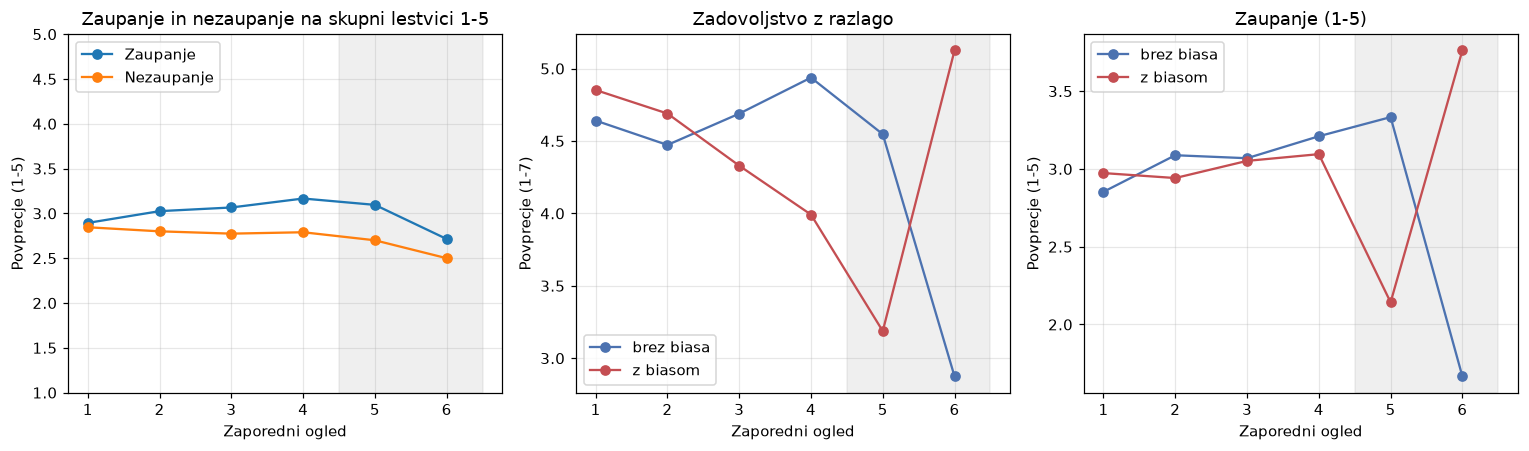

In [16]:
fig, osi = plt.subplots(1, 3, figsize=(14, 4.2))

# Levo: zaupanje in nezaupanje na skupni lestvici 1-5.
for st, oznaka in [("zaupanje_1_5", "Zaupanje"),
                   ("analiza_faktor_nezaupanje_mean", "Nezaupanje")]:
    s = df.groupby("analiza_view_number")[st].mean()
    osi[0].plot(s.index, s.values, marker="o", label=oznaka)
osi[0].set_title("Zaupanje in nezaupanje na skupni lestvici 1-5")
osi[0].set_xlabel("Zaporedni ogled"); osi[0].set_ylabel("Povprecje (1-5)")
osi[0].set_ylim(1, 5); osi[0].legend()

# Sredina: zadovoljstvo, biased proti nebiased.
for vrednost, oznaka, barva in [(0, "brez biasa", "#4C72B0"), (1, "z biasom", "#C44E52")]:
    s = df[df["Biased"] == vrednost].groupby("analiza_view_number")[
        "analiza_zadovoljstvo_q2_mean"].mean()
    osi[1].plot(s.index, s.values, marker="o", color=barva, label=oznaka)
osi[1].set_title("Zadovoljstvo z razlago")
osi[1].set_xlabel("Zaporedni ogled"); osi[1].set_ylabel("Povprecje (1-7)")
osi[1].legend()

# Desno: zaupanje, biased proti nebiased.
for vrednost, oznaka, barva in [(0, "brez biasa", "#4C72B0"), (1, "z biasom", "#C44E52")]:
    s = df[df["Biased"] == vrednost].groupby("analiza_view_number")["zaupanje_1_5"].mean()
    osi[2].plot(s.index, s.values, marker="o", color=barva, label=oznaka)
osi[2].set_title("Zaupanje (1-5)")
osi[2].set_xlabel("Zaporedni ogled"); osi[2].set_ylabel("Povprecje (1-5)")
osi[2].legend()

for ax in osi:
    ax.axvspan(4.5, 6.5, color="grey", alpha=0.12)

plt.tight_layout()
plt.savefig(GRAFI / "05_po_pristranskosti.png", bbox_inches="tight")
plt.show()

Sivo polje označuje kroga 5 in 6, kjer je skupaj le 12 odgovorov — vrednosti tam so
nezanesljive. Zato je poglobljena analiza omejena na kroge 1–4.

### 4.6 Koledarski tedni 1–4

V podatkih sta **dve različni časovni spremenljivki** in nista isto:

| Spremenljivka | Pomen | Enot v 1–4 |
|---|---|---:|
| `analiza_view_number` | zaporedni ogled posameznega udeleženca | 255 |
| `teden` | koledarski teden izvedbe eksperimenta | 195 |

Njuna Spearmanova korelacija je 0,73 — povezani sta, a ne enaki. Vsi udeleženci niso
začeli v prvem tednu: 31 jih je imelo prvi ogled šele v 2. tednu, 14 v 3. tednu.

Zbiranje je potekalo v šestih koledarskih tednih (4. 3. – 10. 4. 2026). Prvi teden zajema
en sam dan (29 odgovorov), šesti pa le 12 odgovorov; jedro podatkov je v tednih 2–5.

In [17]:
datum = pd.to_datetime(df["analiza_itime_date"], errors="coerce")
zap = sorted(datum.dt.isocalendar().week.astype(int).unique())
df["teden"] = datum.dt.isocalendar().week.astype(int).map(
    {t: i + 1 for i, t in enumerate(zap)}
)

pregled = df.groupby("teden").agg(
    odgovorov=("teden", "size"),
    udelezencev=("analiza_resolved_code", "nunique"),
)
pregled["od"] = df.groupby("teden")["analiza_itime_date"].min()
pregled["do"] = df.groupby("teden")["analiza_itime_date"].max()
print(pregled.to_string())
print()
print("Zaporedni ogled proti koledarskemu tednu:")
print(pd.crosstab(df["analiza_view_number"].astype("Int64"), df["teden"]).to_string())

       odgovorov  udelezencev          od          do
teden                                                
1             29           29  2026-03-04  2026-03-04
2             60           57  2026-03-09  2026-03-12
3             59           58  2026-03-16  2026-03-18
4             47           47  2026-03-23  2026-03-26
5             60           60  2026-03-30  2026-04-02
6             12           12  2026-04-09  2026-04-10

Zaporedni ogled proti koledarskemu tednu:
teden                 1   2   3   4   5  6
analiza_view_number                       
1                    29  31  14   3   4  1
2                     0  27  21  18   6  0
3                     0   2  22  17  21  0
4                     0   0   2   9  23  5
5                     0   0   0   0   6  4
6                     0   0   0   0   0  2


Spodaj je analiza iz razdelka 4.3 ponovljena na podmnožici **koledarskih tednov 1–4**
(195 enot, 77 udeležencev), in sicer z obema možnima merama časa.

In [18]:
tedni_14 = df[df["teden"] <= 4]
print(f"Podmnozica: {len(tedni_14)} enot, "
      f"{tedni_14['analiza_resolved_code'].nunique()} udelezencev")


def naklon_casa_x(podatki, stolpec, cas):
    """Naklon poljubne casovne spremenljivke (ogled ali teden)."""
    d = podatki.dropna(subset=[stolpec, cas])
    if d["analiza_resolved_code"].nunique() < 10:
        return None
    m = smf.mixedlm(f"{stolpec} ~ {cas}", d, groups=d["analiza_resolved_code"]).fit()
    return m.params[cas], m.bse[cas], m.pvalues[cas], len(d)


vrstice = []
for cas, oznaka_casa in [("analiza_view_number", "zaporedni ogled"),
                         ("teden", "koledarski teden")]:
    for ime, st in DIM_BIAS.items():
        for skupina, maska in [("brez biasa", tedni_14["Biased"] == 0),
                               ("z biasom", tedni_14["Biased"] == 1)]:
            r = naklon_casa_x(tedni_14[maska], st, cas)
            if r is None:
                continue
            b, se, p, n = r
            vrstice.append({
                "mera casa": oznaka_casa, "dimenzija": ime, "skupina": skupina,
                "N": n, "b": round(b, 3), "SE": round(se, 3), "p": round(p, 3),
                "znacilno": "da" if p < 0.05 else ("mejno" if p < 0.10 else "ne"),
            })

tedni_rezultat = pd.DataFrame(vrstice)
tedni_rezultat.to_csv("nakloni_tedni_1_4.csv", index=False, encoding="utf-8-sig")
tedni_rezultat

Podmnozica: 195 enot, 77 udelezencev


,mera casa,dimenzija,skupina,N,b,SE,p,znacilno
0,zaporedni ogled,Zaupanje (1-5),brez biasa,107,0.057,0.085,0.508,ne
1,zaporedni ogled,Zaupanje (1-5),z biasom,59,-0.007,0.126,0.958,ne
2,zaporedni ogled,Nezaupanje (1-5),brez biasa,107,-0.003,0.087,0.970,ne
3,zaporedni ogled,Nezaupanje (1-5),z biasom,59,0.013,0.119,0.910,ne
4,zaporedni ogled,Zadovoljstvo (1-7),brez biasa,127,-0.117,0.091,0.198,ne
5,zaporedni ogled,Zadovoljstvo (1-7),z biasom,68,-0.332,0.140,0.018,da
6,zaporedni ogled,Izvedljivost (1-5),brez biasa,127,-0.036,0.053,0.498,ne
7,zaporedni ogled,Izvedljivost (1-5),z biasom,68,-0.132,0.076,0.084,mejno
8,zaporedni ogled,Mentalni model (0-1),brez biasa,127,0.014,0.015,0.352,ne
9,zaporedni ogled,Mentalni model (0-1),z biasom,68,-0.014,0.018,0.447,ne


**Kaj to pove.**

Ko je čas merjen kot **zaporedni ogled**, je upad zadovoljstva pri pristranskih primerih
še izrazitejši kot na celotnem vzorcu: b = −0,332, p = 0,018 (proti b = −0,189 na vseh
krogih). Učinek torej ni posledica redkih poznih odgovorov — v strnjenem osrednjem
obdobju je celo močnejši.

Ko je čas merjen kot **koledarski teden**, ni značilen noben učinek (zadovoljstvo z
biasom: b = −0,129, p = 0,296).

Razlika med obema merama je vsebinsko pomembna: upad zadovoljstva sledi temu, **kolikokrat
je posameznik že uporabil sistem**, ne temu, koliko časa je preteklo od začetka
eksperimenta. To govori v prid izpostavljenosti kot razlagi in ne npr. utrujenosti od
sodelovanja v raziskavi.

Za modele je zato ustrezna mera časa `analiza_view_number`, kar je skladno tudi s
specifikacijo (»zaporedni prikaz«).

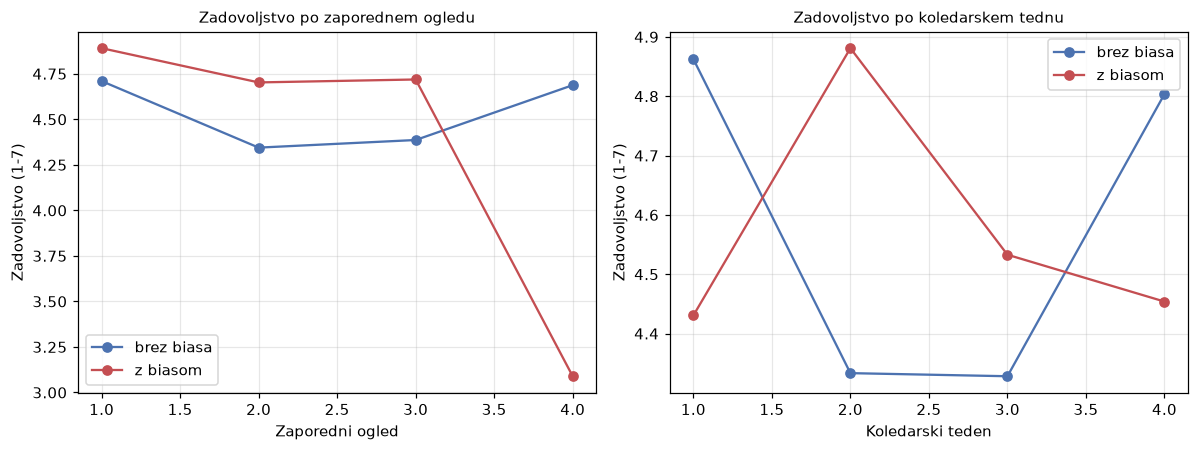

In [19]:
fig, osi = plt.subplots(1, 2, figsize=(11, 4.2))

for ax, (cas, naslov, xoznaka) in zip(
    osi,
    [("analiza_view_number", "Zadovoljstvo po zaporednem ogledu", "Zaporedni ogled"),
     ("teden", "Zadovoljstvo po koledarskem tednu", "Koledarski teden")],
):
    for vrednost, oznaka, barva in [(0, "brez biasa", "#4C72B0"), (1, "z biasom", "#C44E52")]:
        s = tedni_14[tedni_14["Biased"] == vrednost].groupby(cas)[
            "analiza_zadovoljstvo_q2_mean"].mean()
        ax.plot(s.index, s.values, marker="o", color=barva, label=oznaka)
    ax.set_title(naslov, fontsize=10)
    ax.set_xlabel(xoznaka)
    ax.set_ylabel("Zadovoljstvo (1-7)")
    ax.legend()

plt.tight_layout()
plt.savefig(GRAFI / "06_tedni_1_4.png", bbox_inches="tight")
plt.show()

## 5. Zaznana napaka — manjka spremenljivka

Za tretje raziskovalno vprašanje je predvideno:

```
RV3: Ali uporabniki pri večkratni uporabi sistem zaznajo napako?
Zaznana napaka = čas * bias (1+id)
Če je + potem so prepoznali napako, če je – niso
```

Spremenljivke »zaznana napaka«
v podatkih še ni in jo je treba definirati.

Ker je izid dvojiški (zaznal / ni zaznal), gre po specifikaciji
(linearni model za zvezne lestvice, logistični za dvojiške) za **logistični** mešani model, ne linearni:

```python
smf.mixedlm(...)                      # linearni, za trust/distrust/satisfaction
sm.BinomialBayesMixedGLM.from_formula(...)   # ali statsmodels GEE / logisticni MEM
```

**Kandidati za to spremenljivko, ki so že v podatkih:**

| Možnost | Stolpec | Kaj meri | Povprečje |
|---|---|---|---|
| A | `analiza_mm_q3b2_correct` | Q3B: ali je razlaga smiselna (prikazan **enoten** primer za vse) | 0,88 |
| B | `analiza_mm_q3b3_correct` | Q3B: prosti opis, kaj je sporno (omemba spola/nacionalnosti) | 0,08 |
| C | `analiza_mm_q3a_correct` | Q3A: prosti opis lastnega primera | 0,22 |

Pomembna razlika: **Q3B vsem udeležencem prikaže isti primer razlage**, ne njihovega
lastnega življenjepisa. Če je »zaznana napaka« mišljena kot zaznava pristranskosti v
*lastnem* primeru, je edini ustrezen vir Q3A (možnost C). Če pa gre za splošno sposobnost
zaznave pristranskosti, sta ustrezni A ali B.

To je treba dorečiti, preden se model požene.

## 6. Opombe za pisanje magistrskega dela

**Kaj je treba navesti med omejitvami:**

1. **Ni kontrolne skupine brez razlag.** Prvotni načrt je predvideval primerjavo skupine
   z razlagami in brez njih. Izveden eksperiment je imel razlage pri vseh šestih
   življenjepisih, zato H5 ni mogoče testirati kot primerjavo med pogojema.

2. **Pristranskost je vezana na dva konkretna življenjepisa.** Učinka pristranskosti ni
   mogoče ločiti od učinka teh dveh oseb (Živa Kopitar, Amira Bašić).

3. **Besedilo vprašanj Q4A in Q4B je napačno.** Navodilo se glasi »Razvrstite … od
   najpomembnejšega (1) do najmanj pomembnega (7)«, kar opisuje razvrščanje, postavke pa
   so trditve o zaupanju. Preverjeno: 97,5 % udeležencev je odgovarjalo kot na lestvici
   strinjanja (ponovljene vrednosti v vrstici), zato so podatki uporabni — a napako je
   treba priznati.

4. **Dve različici lestvice zaupanja.** 29 enot je izpolnilo starejšo različico in so
   izločene, zato modela za zaupanje in nezaupanje tečeta na N = 238 namesto 267.

5. **Kroga 5 in 6 sta skoraj prazna** (12 odgovorov skupaj).

**Odprto pred zagonom RV3:** definicija spremenljivke »zaznana napaka« (glej razdelek 4).